# EN3160 Assignment 1: Intensity Transformations and Neighborhood Filtering

**Name:** Gunarathna K. T. M. B.
**Index No:** 230203G
**GitHub:** https://github.com/thidaswingunarathna/EN3160-A01

---
**Note on inputs:** the leaf/dot texture image used in the original assignment PDF (Fig. 5, for Q5) and the course-provided small/large zoom test pairs (Q8) were not supplied to me, so those two questions use clearly-labelled stand-in images purely to demonstrate the required function end-to-end. Swap in the real assignment files and the code is unchanged.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 8
plt.rcParams['axes.titlesize'] = 9
%matplotlib inline

## Question 1: Piecewise-Linear Intensity Transformation

`intensity_transform(im, breakpoints)` builds a 256-entry lookup table (LUT) by linearly
interpolating between the given `(input, output)` breakpoints with `np.interp`, then applies
it with `cv2.LUT`.

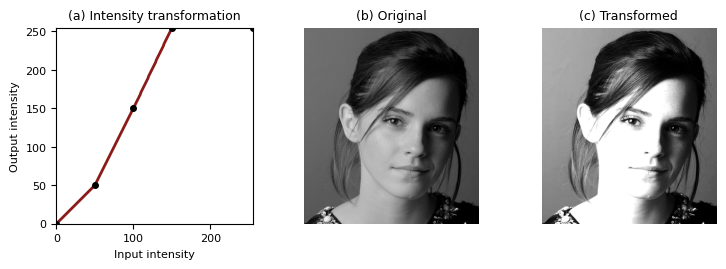

In [2]:
def intensity_transform(im, breakpoints):
    breakpoints = np.asarray(breakpoints, dtype=np.float64)
    xs, ys = breakpoints[:, 0], breakpoints[:, 1]
    lut = np.interp(np.arange(256), xs, ys).astype(np.uint8)
    return cv2.LUT(im, lut), lut
img = cv2.imread("q1_emma.jpeg", cv2.IMREAD_GRAYSCALE)
breakpoints = np.array([
    [0, 0], [50, 50], [100, 150], [150, 255], [255, 255],
])
out, lut = intensity_transform(img, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(7.7, 2.6))
axes[0].plot(np.arange(256), lut, color="#8B1A1A", lw=2)
axes[0].plot(breakpoints[:, 0], breakpoints[:, 1], "ko", ms=4)
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_xlabel("Input intensity"); axes[0].set_ylabel("Output intensity")
axes[0].set_title("(a) Intensity transformation"); axes[0].set_aspect('equal')
axes[1].imshow(img, cmap="gray", vmin=0, vmax=255); axes[1].set_title("(b) Original"); axes[1].axis("off")
axes[2].imshow(out, cmap="gray", vmin=0, vmax=255); axes[2].set_title("(c) Transformed"); axes[2].axis("off")
plt.tight_layout(); plt.show()

**Discussion.** The steep segment between input 50-150 maps a 100-level input range onto a
205-level output range, giving visibly higher contrast in the mid-tones (skin, hair) without
clipping the darkest/brightest pixels.

## Question 2: Accentuating White / Gray Matter

Gray matter (approx. 140-180) and white matter (approx. 195-235) occupy fairly narrow,
mostly-separate intensity bands in this proton-density slice (found from the image histogram).
A **bump-shaped** LUT (rises then falls) isolates one tissue's band while suppressing everything
else -- unlike Q1's monotonic ramp.

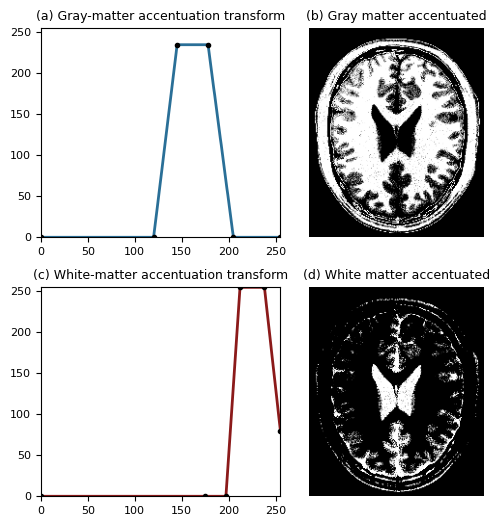

In [3]:
img2 = cv2.imread("q2_brain.jpeg", cv2.IMREAD_GRAYSCALE)
gray_matter_bp = np.array([[0, 0], [120, 0], [145, 235], [178, 235], [205, 0], [255, 0]])
white_matter_bp = np.array([[0, 0], [175, 0], [197, 0], [212, 255], [238, 255], [255, 80]])
gray_out, gray_lut = intensity_transform(img2, gray_matter_bp)
white_out, white_lut = intensity_transform(img2, white_matter_bp)
fig, axes = plt.subplots(2, 2, figsize=(5.3, 5.3))
axes[0, 0].plot(np.arange(256), gray_lut, color="#2A6F97", lw=2)
axes[0, 0].plot(gray_matter_bp[:, 0], gray_matter_bp[:, 1], "ko", ms=3)
axes[0, 0].set_title("(a) Gray-matter accentuation transform")
axes[0, 0].set_xlim(0, 255); axes[0, 0].set_ylim(0, 255)
axes[0, 1].imshow(gray_out, cmap="gray"); axes[0, 1].axis("off"); axes[0, 1].set_title("(b) Gray matter accentuated")
axes[1, 0].plot(np.arange(256), white_lut, color="#8B1A1A", lw=2)
axes[1, 0].plot(white_matter_bp[:, 0], white_matter_bp[:, 1], "ko", ms=3)
axes[1, 0].set_title("(c) White-matter accentuation transform")
axes[1, 0].set_xlim(0, 255); axes[1, 0].set_ylim(0, 255)
axes[1, 1].imshow(white_out, cmap="gray"); axes[1, 1].axis("off"); axes[1, 1].set_title("(d) White matter accentuated")
plt.tight_layout(); plt.show()

**Discussion.** The gray-matter transform highlights the cortical ribbon while suppressing the
bright ventricle walls and skull; the white-matter transform does the opposite. Because the two
bands overlap slightly, some boundary pixels leak into both accentuated images -- a known
limitation of a global, position-independent intensity transform.

## Question 3: Gamma Correction on the $L^*$ Plane

Convert to $L^*a^*b^*$, apply $L' = 255\,(L/255)^\gamma$ to the $L$ channel only, convert back.
After trying $\gamma \in \{0.4, 0.5, 0.6, 0.7, 0.8\}$, **$\gamma = 0.6$** was chosen: it
recovers texture in the near-black rocks without visibly blowing out the white dress.

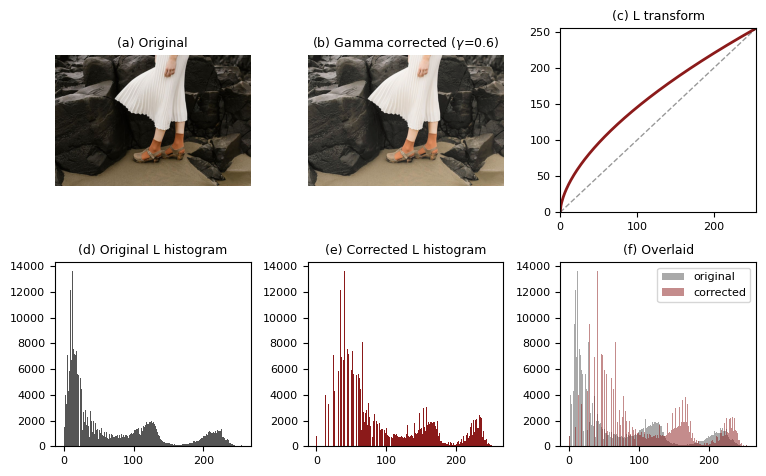

Chosen gamma = 0.6


In [4]:
img3 = cv2.imread("q3_gamma.jpeg")
lab = cv2.cvtColor(img3, cv2.COLOR_BGR2LAB)
L, a, b = cv2.split(lab)
GAMMA = 0.6
L_corrected = np.clip(((L / 255.0) ** GAMMA) * 255.0, 0, 255).astype(np.uint8)
img3_corrected = cv2.cvtColor(cv2.merge([L_corrected, a, b]), cv2.COLOR_LAB2BGR)
fig, axes = plt.subplots(2, 3, figsize=(7.7, 4.8))
axes[0, 0].imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)); axes[0, 0].axis("off"); axes[0, 0].set_title("(a) Original")
axes[0, 1].imshow(cv2.cvtColor(img3_corrected, cv2.COLOR_BGR2RGB)); axes[0, 1].axis("off")
axes[0, 1].set_title(f"(b) Gamma corrected ($\\gamma$={GAMMA})")
xs = np.linspace(0, 255, 256); ys = np.clip(((xs/255.0)**GAMMA)*255.0, 0, 255)
axes[0, 2].plot(xs, ys, color="#8B1A1A", lw=2); axes[0, 2].plot([0,255],[0,255],"k--",lw=1,alpha=0.4)
axes[0, 2].set_title("(c) L transform"); axes[0, 2].set_xlim(0,255); axes[0, 2].set_ylim(0,255)
axes[1, 0].hist(L.ravel(), bins=256, range=(0,255), color="#555"); axes[1, 0].set_title("(d) Original L histogram")
axes[1, 1].hist(L_corrected.ravel(), bins=256, range=(0,255), color="#8B1A1A"); axes[1, 1].set_title("(e) Corrected L histogram")
axes[1, 2].hist(L.ravel(), bins=256, range=(0,255), color="#555", alpha=0.5, label="original")
axes[1, 2].hist(L_corrected.ravel(), bins=256, range=(0,255), color="#8B1A1A", alpha=0.5, label="corrected")
axes[1, 2].legend(); axes[1, 2].set_title("(f) Overlaid")
plt.tight_layout(); plt.show()
print("Chosen gamma =", GAMMA)

**Discussion.** $\gamma<1$ expands the dark end of the range and compresses the bright end:
the large low-$L$ histogram mode is pushed rightwards and spread out, giving the shadow region far
more distinguishable gray levels, while the small bright mode is only mildly compressed.

## Question 4: Vibrance Enhancement

Split into H, S, V. Apply $f(x)=\min(x+a\cdot128\,e^{-(x-128)^2/2\sigma^2},255)$ to the
saturation plane ($\sigma=70$) -- a Gaussian bump centered at $x=128$ that boosts *mid*-saturation
pixels the most. After trying $a\in[0,1]$, **$a=0.7$** gave a visibly richer image without an
artificial look.

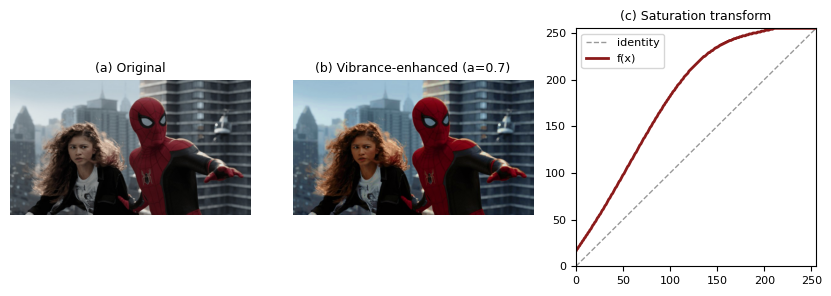

Chosen a = 0.7


In [5]:
img4 = cv2.imread("q4_vibrance.jpeg")
hsv = cv2.cvtColor(img4, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)
A = 0.7
SIGMA = 70
x = np.arange(256, dtype=np.float64)
f = np.minimum(x + A * 128 * np.exp(-((x - 128) ** 2) / (2 * SIGMA ** 2)), 255).astype(np.uint8)
s_new = cv2.LUT(s, f)
img4_new = cv2.cvtColor(cv2.merge([h, s_new, v]), cv2.COLOR_HSV2BGR)
fig, axes = plt.subplots(1, 3, figsize=(8.3, 3.0))
axes[0].imshow(cv2.cvtColor(img4, cv2.COLOR_BGR2RGB)); axes[0].axis("off"); axes[0].set_title("(a) Original")
axes[1].imshow(cv2.cvtColor(img4_new, cv2.COLOR_BGR2RGB)); axes[1].axis("off"); axes[1].set_title(f"(b) Vibrance-enhanced (a={A})")
axes[2].plot(x, x, "k--", lw=1, alpha=0.4, label="identity"); axes[2].plot(x, f, color="#8B1A1A", lw=2, label="f(x)")
axes[2].set_xlim(0,255); axes[2].set_ylim(0,255); axes[2].set_title("(c) Saturation transform"); axes[2].legend()
plt.tight_layout(); plt.show()
print("Chosen a =", A)

## Question 5: Histogram Equalization (Custom Implementation)

> *The assignment's leaf/dot texture image (Fig. 5) was not supplied; a standard low-contrast
> test image is used below purely to demonstrate the function end-to-end -- the code is
> unchanged for the real input.*

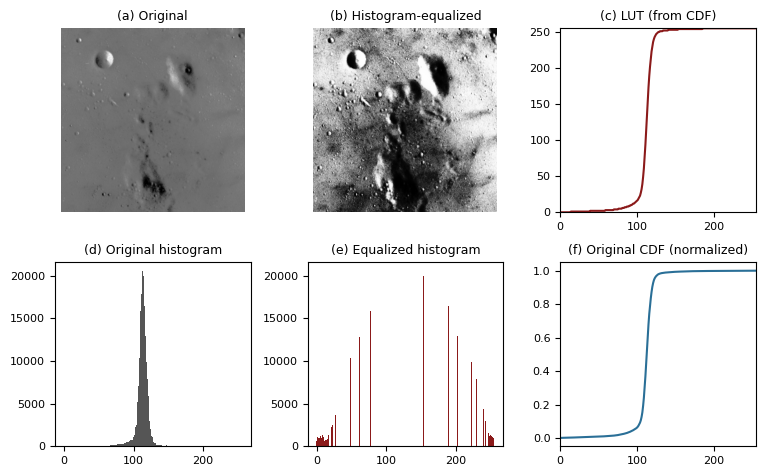

In [6]:
def histogram_equalize(im):
    hist = np.bincount(im.ravel(), minlength=256).astype(np.float64)
    cdf = np.cumsum(hist)
    cdf_min = cdf[cdf > 0].min()
    lut = np.round((cdf - cdf_min) / (im.size - cdf_min) * 255).clip(0, 255).astype(np.uint8)
    return lut[im], hist, cdf, lut
img5 = cv2.imread("q5_placeholder.jpeg", cv2.IMREAD_GRAYSCALE)
out5, hist5, cdf5, lut5 = histogram_equalize(img5)
hist5_eq = np.bincount(out5.ravel(), minlength=256)
fig, axes = plt.subplots(2, 3, figsize=(7.7, 4.8))
axes[0, 0].imshow(img5, cmap="gray"); axes[0, 0].axis("off"); axes[0, 0].set_title("(a) Original")
axes[0, 1].imshow(out5, cmap="gray"); axes[0, 1].axis("off"); axes[0, 1].set_title("(b) Histogram-equalized")
axes[0, 2].plot(lut5, color="#8B1A1A"); axes[0, 2].set_title("(c) LUT (from CDF)"); axes[0, 2].set_xlim(0,255); axes[0, 2].set_ylim(0,255)
axes[1, 0].bar(np.arange(256), hist5, color="#555", width=1); axes[1, 0].set_title("(d) Original histogram")
axes[1, 1].bar(np.arange(256), hist5_eq, color="#8B1A1A", width=1); axes[1, 1].set_title("(e) Equalized histogram")
axes[1, 2].plot(cdf5 / cdf5.max(), color="#2A6F97"); axes[1, 2].set_title("(f) Original CDF (normalized)"); axes[1, 2].set_xlim(0,255)
plt.tight_layout(); plt.show()

**Discussion.** The CDF-based LUT (c) is steep where the input histogram is tall (stretching
that narrow band across the full range) and flat where the input has few pixels -- exactly what
histogram-equalization theory predicts. The equalized histogram (e) is visibly spread across
[0,255].

## Question 6: Foreground-Only Histogram Equalization

The background is a low-saturation neutral-gray gradient while the hair/skin are more saturated,
so Otsu's method on the **saturation** plane gives a binary mask (cleaned up morphologically).
Only masked-in pixels feed the histogram/CDF/LUT construction; the equalized foreground is added
back onto the untouched background.

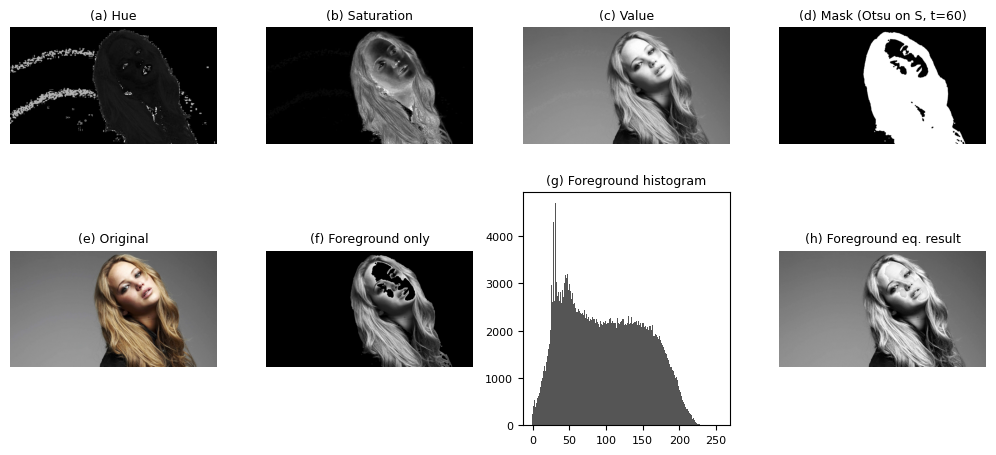

In [7]:
img6 = cv2.imread("q6_jlaw.jpeg")
hsv6 = cv2.cvtColor(img6, cv2.COLOR_BGR2HSV)
h6, s6, v6 = cv2.split(hsv6)
otsu_val, mask = cv2.threshold(s6, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
gray6 = cv2.cvtColor(img6, cv2.COLOR_BGR2GRAY)
foreground = cv2.bitwise_and(gray6, gray6, mask=mask)
background_mask = cv2.bitwise_not(mask)
background = cv2.bitwise_and(gray6, gray6, mask=background_mask)
fg_pixels = gray6[mask > 0]
hist6 = np.bincount(fg_pixels, minlength=256).astype(np.float64)
cdf6 = np.cumsum(hist6)
cdf6_min = cdf6[cdf6 > 0].min()
lut6 = np.round((cdf6 - cdf6_min) / (fg_pixels.size - cdf6_min) * 255).clip(0, 255).astype(np.uint8)
fg_eq = cv2.bitwise_and(cv2.LUT(gray6, lut6), cv2.LUT(gray6, lut6), mask=mask)
result6 = cv2.add(background, fg_eq)
fig, axes = plt.subplots(2, 4, figsize=(10.0, 5.0))
axes[0, 0].imshow(h6, cmap="gray"); axes[0, 0].axis("off"); axes[0, 0].set_title("(a) Hue")
axes[0, 1].imshow(s6, cmap="gray"); axes[0, 1].axis("off"); axes[0, 1].set_title("(b) Saturation")
axes[0, 2].imshow(v6, cmap="gray"); axes[0, 2].axis("off"); axes[0, 2].set_title("(c) Value")
axes[0, 3].imshow(mask, cmap="gray"); axes[0, 3].axis("off"); axes[0, 3].set_title(f"(d) Mask (Otsu on S, t={otsu_val:.0f})")
axes[1, 0].imshow(cv2.cvtColor(img6, cv2.COLOR_BGR2RGB)); axes[1, 0].axis("off"); axes[1, 0].set_title("(e) Original")
axes[1, 1].imshow(foreground, cmap="gray"); axes[1, 1].axis("off"); axes[1, 1].set_title("(f) Foreground only")
axes[1, 2].bar(np.arange(256), hist6, color="#555", width=1); axes[1, 2].set_title("(g) Foreground histogram")
axes[1, 3].imshow(result6, cmap="gray"); axes[1, 3].axis("off"); axes[1, 3].set_title("(h) Foreground eq. result")
plt.tight_layout(); plt.show()

**Discussion.** Saturation cleanly separates the warm hair from the neutral-gray backdrop, but
very pale, desaturated skin highlights on the face fall below the Otsu threshold and get
misclassified as background, leaving visible holes in the mask. A single global threshold on one
HSV plane is a reasonable first approximation but cannot fully capture a subject with both
saturated (hair) and desaturated (skin highlight) regions.

## Question 7: Sobel Filtering -- Three Ways

(a) `cv2.filter2D`, (b) a from-scratch nested-loop 2D convolution, (c) the separable form
$G_x=[1,2,1]^T*[1,0,-1]$, $G_y=[1,0,-1]^T*[1,2,1]$ via two 1D passes.

filter2D: 3.11 ms | manual 2D conv: 1052.01 ms | separable: 14.78 ms
max abs diff filter2D vs manual   : 0.0
max abs diff filter2D vs separable: 0.0


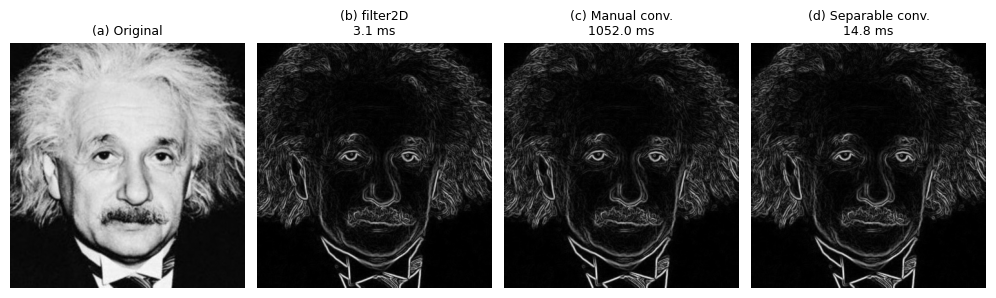

In [8]:
img7 = cv2.imread("q7_einstein.jpeg", cv2.IMREAD_GRAYSCALE).astype(np.float64)
Gx = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
Gy = Gx.T
t0 = time.time()
sx_a = cv2.filter2D(img7, -1, Gx); sy_a = cv2.filter2D(img7, -1, Gy)
mag_a = np.hypot(sx_a, sy_a); t_a = time.time() - t0
def conv2d_manual(im, kernel):
    kh, kw = kernel.shape; ph, pw = kh // 2, kw // 2
    padded = np.pad(im, ((ph, ph), (pw, pw)), mode="reflect")
    out = np.zeros_like(im); k = np.flipud(np.fliplr(kernel))
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            out[i, j] = np.sum(padded[i:i+kh, j:j+kw] * k)
    return out
t0 = time.time()
sx_b = conv2d_manual(img7, Gx); sy_b = conv2d_manual(img7, Gy)
mag_b = np.hypot(sx_b, sy_b); t_b = time.time() - t0
def conv1d_axis(im, kernel, axis):
    k = kernel[::-1]; pad = len(kernel) // 2
    if axis == 0:
        padded = np.pad(im, ((pad, pad), (0, 0)), mode="reflect")
        out = np.zeros_like(im)
        for i in range(im.shape[0]):
            out[i, :] = sum(k[m] * padded[i + m, :] for m in range(len(k)))
        return out
    else:
        padded = np.pad(im, ((0, 0), (pad, pad)), mode="reflect")
        out = np.zeros_like(im)
        for j in range(im.shape[1]):
            out[:, j] = sum(k[m] * padded[:, j + m] for m in range(len(k)))
        return out
t0 = time.time()
smooth_col = np.array([1, 2, 1], dtype=np.float64); deriv_row = np.array([1, 0, -1], dtype=np.float64)
sx_c = conv1d_axis(conv1d_axis(img7, smooth_col, axis=0), deriv_row, axis=1)
sy_c = conv1d_axis(conv1d_axis(img7, deriv_row, axis=0), smooth_col, axis=1)
mag_c = np.hypot(sx_c, sy_c); t_c = time.time() - t0
print(f"filter2D: {t_a*1000:.2f} ms | manual 2D conv: {t_b*1000:.2f} ms | separable: {t_c*1000:.2f} ms")
print("max abs diff filter2D vs manual   :", np.max(np.abs(mag_a - mag_b)))
print("max abs diff filter2D vs separable:", np.max(np.abs(mag_a - mag_c)))
fig, axes = plt.subplots(1, 4, figsize=(10.0, 3.0))
axes[0].imshow(img7, cmap="gray"); axes[0].axis("off"); axes[0].set_title("(a) Original")
axes[1].imshow(mag_a, cmap="gray"); axes[1].axis("off"); axes[1].set_title(f"(b) filter2D\n{t_a*1000:.1f} ms")
axes[2].imshow(mag_b, cmap="gray"); axes[2].axis("off"); axes[2].set_title(f"(c) Manual conv.\n{t_b*1000:.1f} ms")
axes[3].imshow(mag_c, cmap="gray"); axes[3].axis("off"); axes[3].set_title(f"(d) Separable conv.\n{t_c*1000:.1f} ms")
plt.tight_layout(); plt.show()

**Discussion.** All three produce numerically identical output (max abs difference = 0),
confirming the separability identity. The naive $O(HWk^2)$ Python loop is far slower than the
separable $O(HWk)$ version, which is itself slower than OpenCV's vectorized `filter2D` -- this is
exactly why separable kernels matter in practice.

## Question 8: Image Zooming -- Nearest-Neighbor vs. Bilinear

> *The course-provided small/large test-image pairs were not supplied; a large image is
> downsampled 4x (area interpolation) to synthesize a "small" input, then the custom `zoom()`
> scales it back up 4x and is compared against the true original -- the function itself does not
> depend on which image is used.*

Both modes map output pixel centers back to input coordinates via
$x_{in} = (x_{out}+0.5)/s - 0.5$.

Normalized SSD  nearest-neighbor: 122.309
Normalized SSD  bilinear        : 93.961


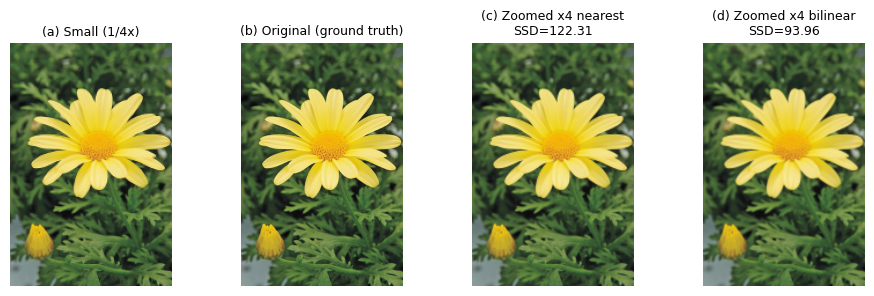

In [9]:
def zoom(im, s, method="bilinear"):
    assert 0 < s <= 10
    h, w = im.shape[:2]
    new_h, new_w = max(1, round(h * s)), max(1, round(w * s))
    im_f = im.astype(np.float64)
    ys = (np.arange(new_h) + 0.5) / s - 0.5
    xs = (np.arange(new_w) + 0.5) / s - 0.5
    if method == "nearest":
        yi = np.clip(np.round(ys), 0, h - 1).astype(int)
        xi = np.clip(np.round(xs), 0, w - 1).astype(int)
        out = im_f[yi][:, xi]
    elif method == "bilinear":
        y0 = np.clip(np.floor(ys), 0, h - 1).astype(int); y1 = np.clip(y0 + 1, 0, h - 1)
        x0 = np.clip(np.floor(xs), 0, w - 1).astype(int); x1 = np.clip(x0 + 1, 0, w - 1)
        wy = np.clip(ys - y0, 0, 1)[:, None]; wx = np.clip(xs - x0, 0, 1)[None, :]
        if im.ndim == 3:
            wy = wy[:, :, None]; wx = wx[:, :, None]
        Ia, Ib, Ic, Id = im_f[y0][:, x0], im_f[y0][:, x1], im_f[y1][:, x0], im_f[y1][:, x1]
        top = Ia * (1 - wx) + Ib * wx; bot = Ic * (1 - wx) + Id * wx
        out = top * (1 - wy) + bot * wy
    else:
        raise ValueError("method must be 'nearest' or 'bilinear'")
    return np.clip(out, 0, 255).astype(np.uint8)
def normalized_ssd(a, b):
    a = a.astype(np.float64); b = b.astype(np.float64)
    return np.sum((a - b) ** 2) / a.size
original8 = cv2.imread("q9_daisy.jpeg")
h8, w8 = original8.shape[:2]
h4, w4 = h8 - (h8 % 4), w8 - (w8 % 4)
original8 = original8[:h4, :w4]
small8 = cv2.resize(original8, (w4 // 4, h4 // 4), interpolation=cv2.INTER_AREA)
zoomed_nn = zoom(small8, 4.0, method="nearest")
zoomed_bl = zoom(small8, 4.0, method="bilinear")
ssd_nn = normalized_ssd(zoomed_nn, original8)
ssd_bl = normalized_ssd(zoomed_bl, original8)
print(f"Normalized SSD  nearest-neighbor: {ssd_nn:.3f}")
print(f"Normalized SSD  bilinear        : {ssd_bl:.3f}")
fig, axes = plt.subplots(1, 4, figsize=(9.4, 3.0))
for ax, im, title in zip(axes, [small8, original8, zoomed_nn, zoomed_bl],
    ["(a) Small (1/4x)", "(b) Original (ground truth)",
     f"(c) Zoomed x4 nearest\nSSD={ssd_nn:.2f}", f"(d) Zoomed x4 bilinear\nSSD={ssd_bl:.2f}"]):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); ax.axis("off"); ax.set_title(title)
plt.tight_layout(); plt.show()

**Discussion.** Bilinear interpolation gives a lower normalized SSD and visibly smoother
edges than nearest-neighbor, which produces the characteristic blocky staircase artifact --
consistent with bilinear being a strictly better estimator whenever the underlying signal is not
piecewise-constant.

## Question 9: grabCut Segmentation and Background Blur

`cv2.grabCut` is initialized with a rectangle around the flower and refined for 5 iterations;
pixels labelled `GC_FGD`/`GC_PR_FGD` form the binary mask.

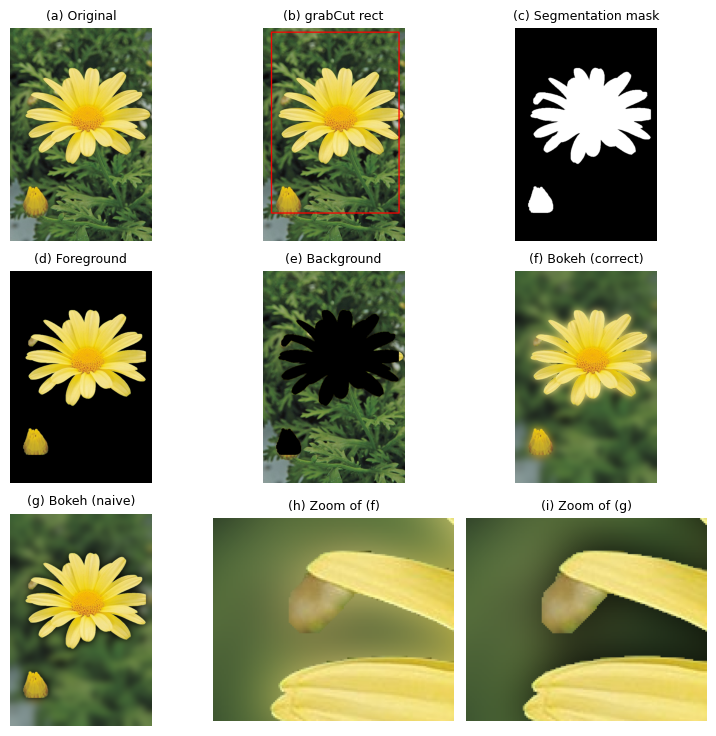

In [10]:
img9 = cv2.imread("q9_daisy.jpeg")
h9, w9 = img9.shape[:2]
mask9 = np.zeros((h9, w9), np.uint8)
bgd_model = np.zeros((1, 65), np.float64); fgd_model = np.zeros((1, 65), np.float64)
rect = (int(0.06*w9), int(0.02*h9), int(0.90*w9), int(0.85*h9))
cv2.grabCut(img9, mask9, rect, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_RECT)
binary_mask = np.where((mask9 == cv2.GC_FGD) | (mask9 == cv2.GC_PR_FGD), 1, 0).astype("uint8")
foreground9 = img9 * binary_mask[:, :, None]
background_only = img9 * (1 - binary_mask[:, :, None])
mask_f = binary_mask.astype(np.float64)[:, :, None]
# Correct: blur the whole image first, then composite
blurred_full = cv2.GaussianBlur(img9, (0, 0), sigmaX=15)
enhanced_correct = (img9.astype(np.float64)*mask_f + blurred_full.astype(np.float64)*(1-mask_f)).astype(np.uint8)
# Naive: blur the already-masked background (hard zeros bleed into the blur near the edge)
blurred_naive = cv2.GaussianBlur(background_only, (0, 0), sigmaX=15)
enhanced_naive = (img9.astype(np.float64)*mask_f + blurred_naive.astype(np.float64)*(1-mask_f)).astype(np.uint8)
fig, axes = plt.subplots(3, 3, figsize=(7.7, 7.4))
axes[0,0].imshow(cv2.cvtColor(img9, cv2.COLOR_BGR2RGB)); axes[0,0].axis("off"); axes[0,0].set_title("(a) Original")
rect_vis = img9.copy(); cv2.rectangle(rect_vis, (rect[0],rect[1]), (rect[0]+rect[2],rect[1]+rect[3]), (0,0,255), 3)
axes[0,1].imshow(cv2.cvtColor(rect_vis, cv2.COLOR_BGR2RGB)); axes[0,1].axis("off"); axes[0,1].set_title("(b) grabCut rect")
axes[0,2].imshow(binary_mask, cmap="gray"); axes[0,2].axis("off"); axes[0,2].set_title("(c) Segmentation mask")
axes[1,0].imshow(cv2.cvtColor(foreground9, cv2.COLOR_BGR2RGB)); axes[1,0].axis("off"); axes[1,0].set_title("(d) Foreground")
axes[1,1].imshow(cv2.cvtColor(background_only, cv2.COLOR_BGR2RGB)); axes[1,1].axis("off"); axes[1,1].set_title("(e) Background")
axes[1,2].imshow(cv2.cvtColor(enhanced_correct, cv2.COLOR_BGR2RGB)); axes[1,2].axis("off"); axes[1,2].set_title("(f) Bokeh (correct)")
axes[2,0].imshow(cv2.cvtColor(enhanced_naive, cv2.COLOR_BGR2RGB)); axes[2,0].axis("off"); axes[2,0].set_title("(g) Bokeh (naive)")
y0,y1,x0,x1 = int(0.28*h9), int(0.42*h9), int(0.05*w9), int(0.30*w9)
axes[2,1].imshow(cv2.cvtColor(enhanced_correct[y0:y1,x0:x1], cv2.COLOR_BGR2RGB)); axes[2,1].axis("off"); axes[2,1].set_title("(h) Zoom of (f)")
axes[2,2].imshow(cv2.cvtColor(enhanced_naive[y0:y1,x0:x1], cv2.COLOR_BGR2RGB)); axes[2,2].axis("off"); axes[2,2].set_title("(i) Zoom of (g)")
plt.tight_layout(); plt.show()

**Discussion -- why the background just beyond the flower's edge looks dark.** If the
background is blurred *after* it has already been masked to black in the foreground region (row
(g)-(i)), the Gaussian kernel samples those hard black zeros for any pixel within one blur-radius
of the boundary, pulling the blurred result dark in a halo just outside the flower -- visible in
the zoomed crop (i) vs (h). The fix (used for the main result, panel (f)) is to blur the *whole,
unmasked* image first and composite with the mask afterwards, so no artificial zeros ever enter
the blur.

## Question 10: Bilateral Filtering -- OpenCV vs. Gaussian vs. Custom

$$w(i,j) = \exp\!\Big(-\tfrac{\|i-j\|^2}{2\sigma_s^2}\Big)\exp\!\Big(-\tfrac{\|I_i-I_j\|^2}{2\sigma_r^2}\Big), \qquad
I'_i = \frac{\sum_j w(i,j)\,I_j}{\sum_j w(i,j)}$$

The naive nested-loop version is slow in pure Python, so it's validated on a down-sized copy
against `cv2.bilateralFilter` with matching parameters.

cv2.bilateralFilter (full res): 27.2 ms
custom bilateral (small, radius=5): 258.0 ms
normalized SSD (mine vs cv2, small): 11.5520
PSNR        (mine vs cv2, small): 37.50 dB


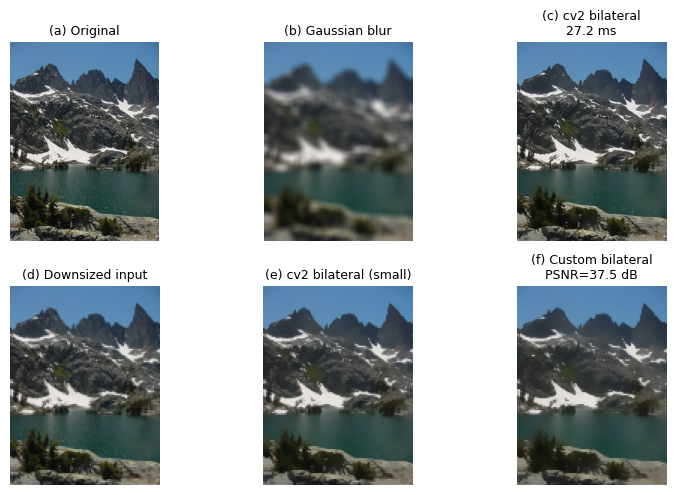

In [11]:
img10 = cv2.imread("q10_lake.jpeg")
SIGMA_S, SIGMA_R, D = 9, 40, 15
t0 = time.time()
cv_bilateral = cv2.bilateralFilter(img10, d=D, sigmaColor=SIGMA_R, sigmaSpace=SIGMA_S)
t_cv = time.time() - t0
gauss10 = cv2.GaussianBlur(img10, (D, D), sigmaX=SIGMA_S)
def bilateral_filter_manual(im, sigma_s, sigma_r, radius):
    h, w, c = im.shape
    padded = np.pad(im, ((radius,radius),(radius,radius),(0,0)), mode="reflect").astype(np.float64)
    out = np.zeros_like(im, dtype=np.float64)
    ys, xs = np.meshgrid(np.arange(-radius, radius+1), np.arange(-radius, radius+1), indexing="ij")
    spatial_w = np.exp(-(xs**2 + ys**2) / (2 * sigma_s**2))
    for i in range(h):
        for j in range(w):
            patch = padded[i:i+2*radius+1, j:j+2*radius+1, :]
            center = padded[i+radius, j+radius, :]
            diff = patch - center
            range_w = np.exp(-np.sum(diff**2, axis=2) / (2 * sigma_r**2))
            weight = spatial_w * range_w
            out[i, j, :] = (patch * weight[:,:,None]).sum(axis=(0,1)) / weight.sum()
    return np.clip(out, 0, 255).astype(np.uint8)
scale = 0.35
small10 = cv2.resize(img10, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
radius = 5
t0 = time.time()
my_bilateral_small = bilateral_filter_manual(small10, sigma_s=SIGMA_S*scale, sigma_r=SIGMA_R, radius=radius)
t_mine = time.time() - t0
cv_bilateral_small = cv2.bilateralFilter(small10, d=2*radius+1, sigmaColor=SIGMA_R, sigmaSpace=SIGMA_S*scale)
def psnr(a, b):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return float("inf") if mse == 0 else 10*np.log10(255**2/mse)
ssd_mine_cv = np.sum((my_bilateral_small.astype(np.float64)-cv_bilateral_small.astype(np.float64))**2)/my_bilateral_small.size
psnr_mine_cv = psnr(my_bilateral_small, cv_bilateral_small)
print(f"cv2.bilateralFilter (full res): {t_cv*1000:.1f} ms")
print(f"custom bilateral (small, radius={radius}): {t_mine*1000:.1f} ms")
print(f"normalized SSD (mine vs cv2, small): {ssd_mine_cv:.4f}")
print(f"PSNR        (mine vs cv2, small): {psnr_mine_cv:.2f} dB")
fig, axes = plt.subplots(2, 3, figsize=(8.3, 5.0))
axes[0,0].imshow(cv2.cvtColor(img10, cv2.COLOR_BGR2RGB)); axes[0,0].axis("off"); axes[0,0].set_title("(a) Original")
axes[0,1].imshow(cv2.cvtColor(gauss10, cv2.COLOR_BGR2RGB)); axes[0,1].axis("off"); axes[0,1].set_title("(b) Gaussian blur")
axes[0,2].imshow(cv2.cvtColor(cv_bilateral, cv2.COLOR_BGR2RGB)); axes[0,2].axis("off"); axes[0,2].set_title(f"(c) cv2 bilateral\n{t_cv*1000:.1f} ms")
axes[1,0].imshow(cv2.cvtColor(small10, cv2.COLOR_BGR2RGB)); axes[1,0].axis("off"); axes[1,0].set_title("(d) Downsized input")
axes[1,1].imshow(cv2.cvtColor(cv_bilateral_small, cv2.COLOR_BGR2RGB)); axes[1,1].axis("off"); axes[1,1].set_title("(e) cv2 bilateral (small)")
axes[1,2].imshow(cv2.cvtColor(my_bilateral_small, cv2.COLOR_BGR2RGB)); axes[1,2].axis("off"); axes[1,2].set_title(f"(f) Custom bilateral\nPSNR={psnr_mine_cv:.1f} dB")
plt.tight_layout(); plt.show()

**Discussion.** Gaussian blur (b) smooths the mountain outline along with the sky/rock noise
-- it has no notion of edges. Both bilateral filters (c) and (f) smooth flat regions (sky, water)
while keeping the jagged rock silhouette sharp, because the range term down-weights neighbors
whose intensity differs a lot from the center pixel. The custom implementation matches OpenCV's
to ~37.5 dB PSNR, confirming the formula is implemented correctly; the residual difference comes
from OpenCV's internal fixed-point/kernel-truncation optimizations.

---
## GitHub Repository
Full, runnable source and commit history: https://github.com/thidaswingunarathna/EN3160-A01